# Coletando o theta estimado

## Experimento Validação

- 10 episódios de Teste
- 10 episódios de Validação
- 20 agentes

* Cada agente é treinado com todos os passos dos episódios de teste exceto o último e testado no último passo
* Resultado intermedário é a médias do RMSE dos agentes em cada episódio de teste
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é a médias do RMSE dos agentes em cada passo dos episódios de teste

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmbrl.model import *
from pmbrl.data import *
from pmbrl.experiment import *


In [2]:
n_episodes = 100

# env = gym.make("custom/DiscreteCartPole-v1")
env = gym.make("custom/CartPole-v1")

data = [generate_episode(env=env, seed=i) for i in range(n_episodes)]
# for i in data:
#     print(i.shape)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


In [3]:
for epi in data:
    print(epi[0])

[ 0.0174  0.0126  1.      1.      0.85    1.8     0.0176 -0.1641]
[-0.0356  0.0449  0.      1.      0.02    1.7    -0.0347  0.123 ]
[ 0.0314 -0.0408  0.      1.      0.43    0.3     0.0306  0.6235]
[ 0.0301  0.0082  1.      1.      0.42    0.6     0.0303 -0.2997]
[ 0.0476 -0.0419  1.      1.      0.4     1.3     0.0468 -0.1785]
[ 0.0015 -0.0214  1.      1.      0.57    0.8     0.0011 -0.2998]
[-0.0131 -0.0126  1.      1.      0.28    0.     -0.0133 -0.2262]
[ 0.0276 -0.0275  1.      1.      0.46    1.6     0.027  -0.1479]
[-0.0181  0.0289  1.      1.      0.29    1.7    -0.0176 -0.0731]
[0.0103 0.0278 0.     1.     0.85   1.7    0.0109 0.2206]
[ 0.0328 -0.0351  0.      1.      0.86    1.3     0.0321  0.227 ]
[ 0.0101 -0.0471  0.      1.      0.29    0.5     0.0092  0.2965]
[-0.0311 -0.0321  1.      1.      0.28    0.8    -0.0317 -0.2496]
[ 0.0311 -0.0239  1.      1.      0.04    0.5     0.0306 -0.2947]
[0.0203 0.036  0.     1.     0.2    1.3    0.021  0.1601]
[-0.0156 -0.0455  1.      

In [4]:
n_agents = 1

pmbrl = [Model(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]
# mbrl = [ModelBase(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]

In [5]:
training = { # Traning:
    "mode": "all", # Mode of the PMBRL (All: learn parameters and Transitions)
    "debug": False, # Number of epochs on training
    "num_epochs": 500, # Number of epochs on training
}

def run(data, models, verbose=False):
    results = []
    for i, epi in enumerate(data):
        if verbose:
            print(f'Episode {i}...')
        X, y = build_train_data(epi)
        for j, agent in enumerate(models):
            if verbose:
                print(f'Agent {j}...')
            agent.train(X[:-1], y[:-1, :-2], **training)
            s,r = agent.sample(X[-1:], mode=training['mode'])
            p,_ = agent.sample(X[-1:, :-1], mode='param')
            results.append(
                torch.concat([
                    torch.tensor([i, j]),
                    torch.mean((s - y[-1:,:2])**2, axis=0)**.5,
                    torch.mean((r - y[-1:,2])**2, axis=0)**.5,
                    p[0],
                    y[-1, 3:]
                ], axis=0)
            )
    return pd.DataFrame(np.array(results), columns=['epi', 'agent', 's_0', 's_1', 'r', 'p_0', 'p_1', 'reff_p_0', 'reff_p_1']) 

# pmbrl_results = run(data, pmbrl)
# mbrl_results = run(data, mbrl)

In [6]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

# pmbrl_plot = pmbrl_results.groupby(by='epi').median()[['s_0','s_1','r', 'p_0', 'p_1']]

Training pmbrl...
Episode 0...
Agent 0...
Episode 1...
Agent 0...
Episode 2...
Agent 0...
Episode 3...
Agent 0...
Episode 4...
Agent 0...
Episode 5...
Agent 0...
Episode 6...
Agent 0...
Episode 7...
Agent 0...
Episode 8...
Agent 0...
Episode 9...
Agent 0...
Episode 10...
Agent 0...
Episode 11...
Agent 0...
Episode 12...
Agent 0...
Episode 13...
Agent 0...
Episode 14...
Agent 0...
Episode 15...
Agent 0...
Episode 16...
Agent 0...
Episode 17...
Agent 0...
Episode 18...
Agent 0...
Episode 19...
Agent 0...
Episode 20...
Agent 0...
Episode 21...
Agent 0...
Episode 22...
Agent 0...
Episode 23...
Agent 0...
Episode 24...
Agent 0...
Episode 25...
Agent 0...
Episode 26...
Agent 0...
Episode 27...
Agent 0...
Episode 28...
Agent 0...
Episode 29...
Agent 0...
Episode 30...
Agent 0...
Episode 31...
Agent 0...
Episode 32...
Agent 0...
Episode 33...
Agent 0...
Episode 34...
Agent 0...
Episode 35...
Agent 0...
Episode 36...
Agent 0...
Episode 37...
Agent 0...
Episode 38...
Agent 0...
Episode 39...
Age

In [7]:
# print('Training mbrl...')
# mbrl_results = run(data, mbrl, verbose=True)
# print('mbrl done!')

# mbrl_plot = mbrl_results.groupby(by='epi').median()[['s_0','s_1','r', 'p_0', 'p_1']]

In [8]:
def add_plot(name, d, axis, reffs):
    # reff = np.zeros(data.shape[0])
    axis[0].set_ylabel(name)
    axis[0].set_ylabel(name)

    axis[0].plot(d['p_0'], color = 'g')
    axis[0].plot(reffs[0], linestyle = 'dotted', color = 'g')
    axis[0].set_yticks(np.arange(5) - 2)

    axis[1].plot(d['p_1'], color = 'b')
    axis[1].plot(reffs[1], linestyle = 'dotted', color = 'b')
    axis[1].set_yticks(np.arange(5) - 2)


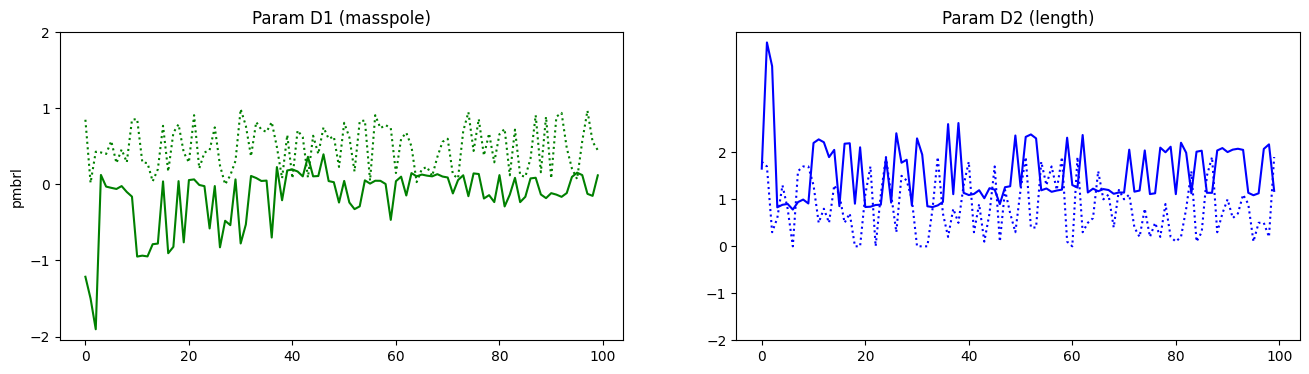

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].set_title('Param D1 (masspole)')
axs[1].set_title('Param D2 (length)')

add_plot(f'pmbrl', pmbrl_results, axs, (pmbrl_results.reff_p_0, pmbrl_results.reff_p_1))

plt.show()

# Teste

In [10]:
n_episodes = 10

data = [generate_episode() for _ in range(n_episodes)]
for i in data:
    print(i.shape)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


(72, 8)
(38, 8)
(64, 8)
(44, 8)
(100, 8)
(100, 8)
(76, 8)
(26, 8)
(21, 8)
(26, 8)


In [11]:
def run(data, models, verbose=False):
    results = []
    for i, epi in enumerate(data):
        if verbose:
            print(f'Episode {i}...')
        X, y = build_train_data(epi)
        for j, agent in enumerate(models):
            if verbose:
                print(f'Agent {j}...')
            for k, (feature, target) in enumerate(zip(X,y)):
                s,r = agent.sample(torch.unsqueeze(feature, axis=0), mode=training['mode'])
                p,_ = agent.sample(torch.unsqueeze(feature, axis=0)[:, :-1], mode='param')
                results.append(
                    torch.concat([
                        torch.tensor([i, j, k]),
                        torch.mean((s - target[:2])**2, axis=0)**.5,
                        torch.mean((r - target[2])**2, axis=0)**.5,
                        p[0],
                        y[-1, 3:]
                ], axis=0)
            )
    return pd.DataFrame(np.array(results), columns=['epi', 'agent', 'step', 's_0', 's_1', 'r', 'p_0', 'p_1', 'reff_p_0', 'reff_p_1']) 


In [12]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

# pmbrl_plot = pmbrl_results.groupby(by='step').mean()[['s_0','s_1','r', 'p_0','p_1']]

Training pmbrl...
Episode 0...
Agent 0...
Episode 1...
Agent 0...
Episode 2...
Agent 0...
Episode 3...
Agent 0...
Episode 4...
Agent 0...
Episode 5...
Agent 0...
Episode 6...
Agent 0...
Episode 7...
Agent 0...
Episode 8...
Agent 0...
Episode 9...
Agent 0...
pmbrl done!


In [13]:
pmbrl_plot = pmbrl_results[pmbrl_results['epi']==0.0]#.groupby(by='step').mean()[['s_0','s_1','r', 'p_0','p_1']]
pmbrl_plot

,epi,agent,step,s_0,s_1,r,p_0,p_1,reff_p_0,reff_p_1
0,0.0,0.0,0.0,0.002605,0.127944,0.5,0.022274,1.678446,0.65,1.7
1,0.0,0.0,1.0,0.001053,0.063592,0.5,0.016965,1.689797,0.65,1.7
2,0.0,0.0,2.0,0.000970,0.039321,0.5,0.022244,1.715262,0.65,1.7
3,0.0,0.0,3.0,0.000947,0.040894,0.5,0.024420,1.719966,0.65,1.7
4,0.0,0.0,4.0,0.000652,0.035697,0.5,0.027526,1.719028,0.65,1.7
...,...,...,...,...,...,...,...,...,...,...
66,0.0,0.0,66.0,0.014144,0.277289,0.5,-0.024685,2.002936,0.65,1.7
67,0.0,0.0,67.0,0.022694,0.274235,0.5,-0.024456,2.018291,0.65,1.7
68,0.0,0.0,68.0,0.015211,0.342517,0.5,-0.035791,2.025797,0.65,1.7
69,0.0,0.0,69.0,0.024940,0.295242,0.5,-0.032739,2.059503,0.65,1.7


In [14]:
# print('Training mbrl...')
# mbrl_results = run(data, mbrl, verbose=True)
# print('mbrl done!')

# mbrl_plot = mbrl_results.groupby(by='step').mean()[['s_0','s_1','r']]

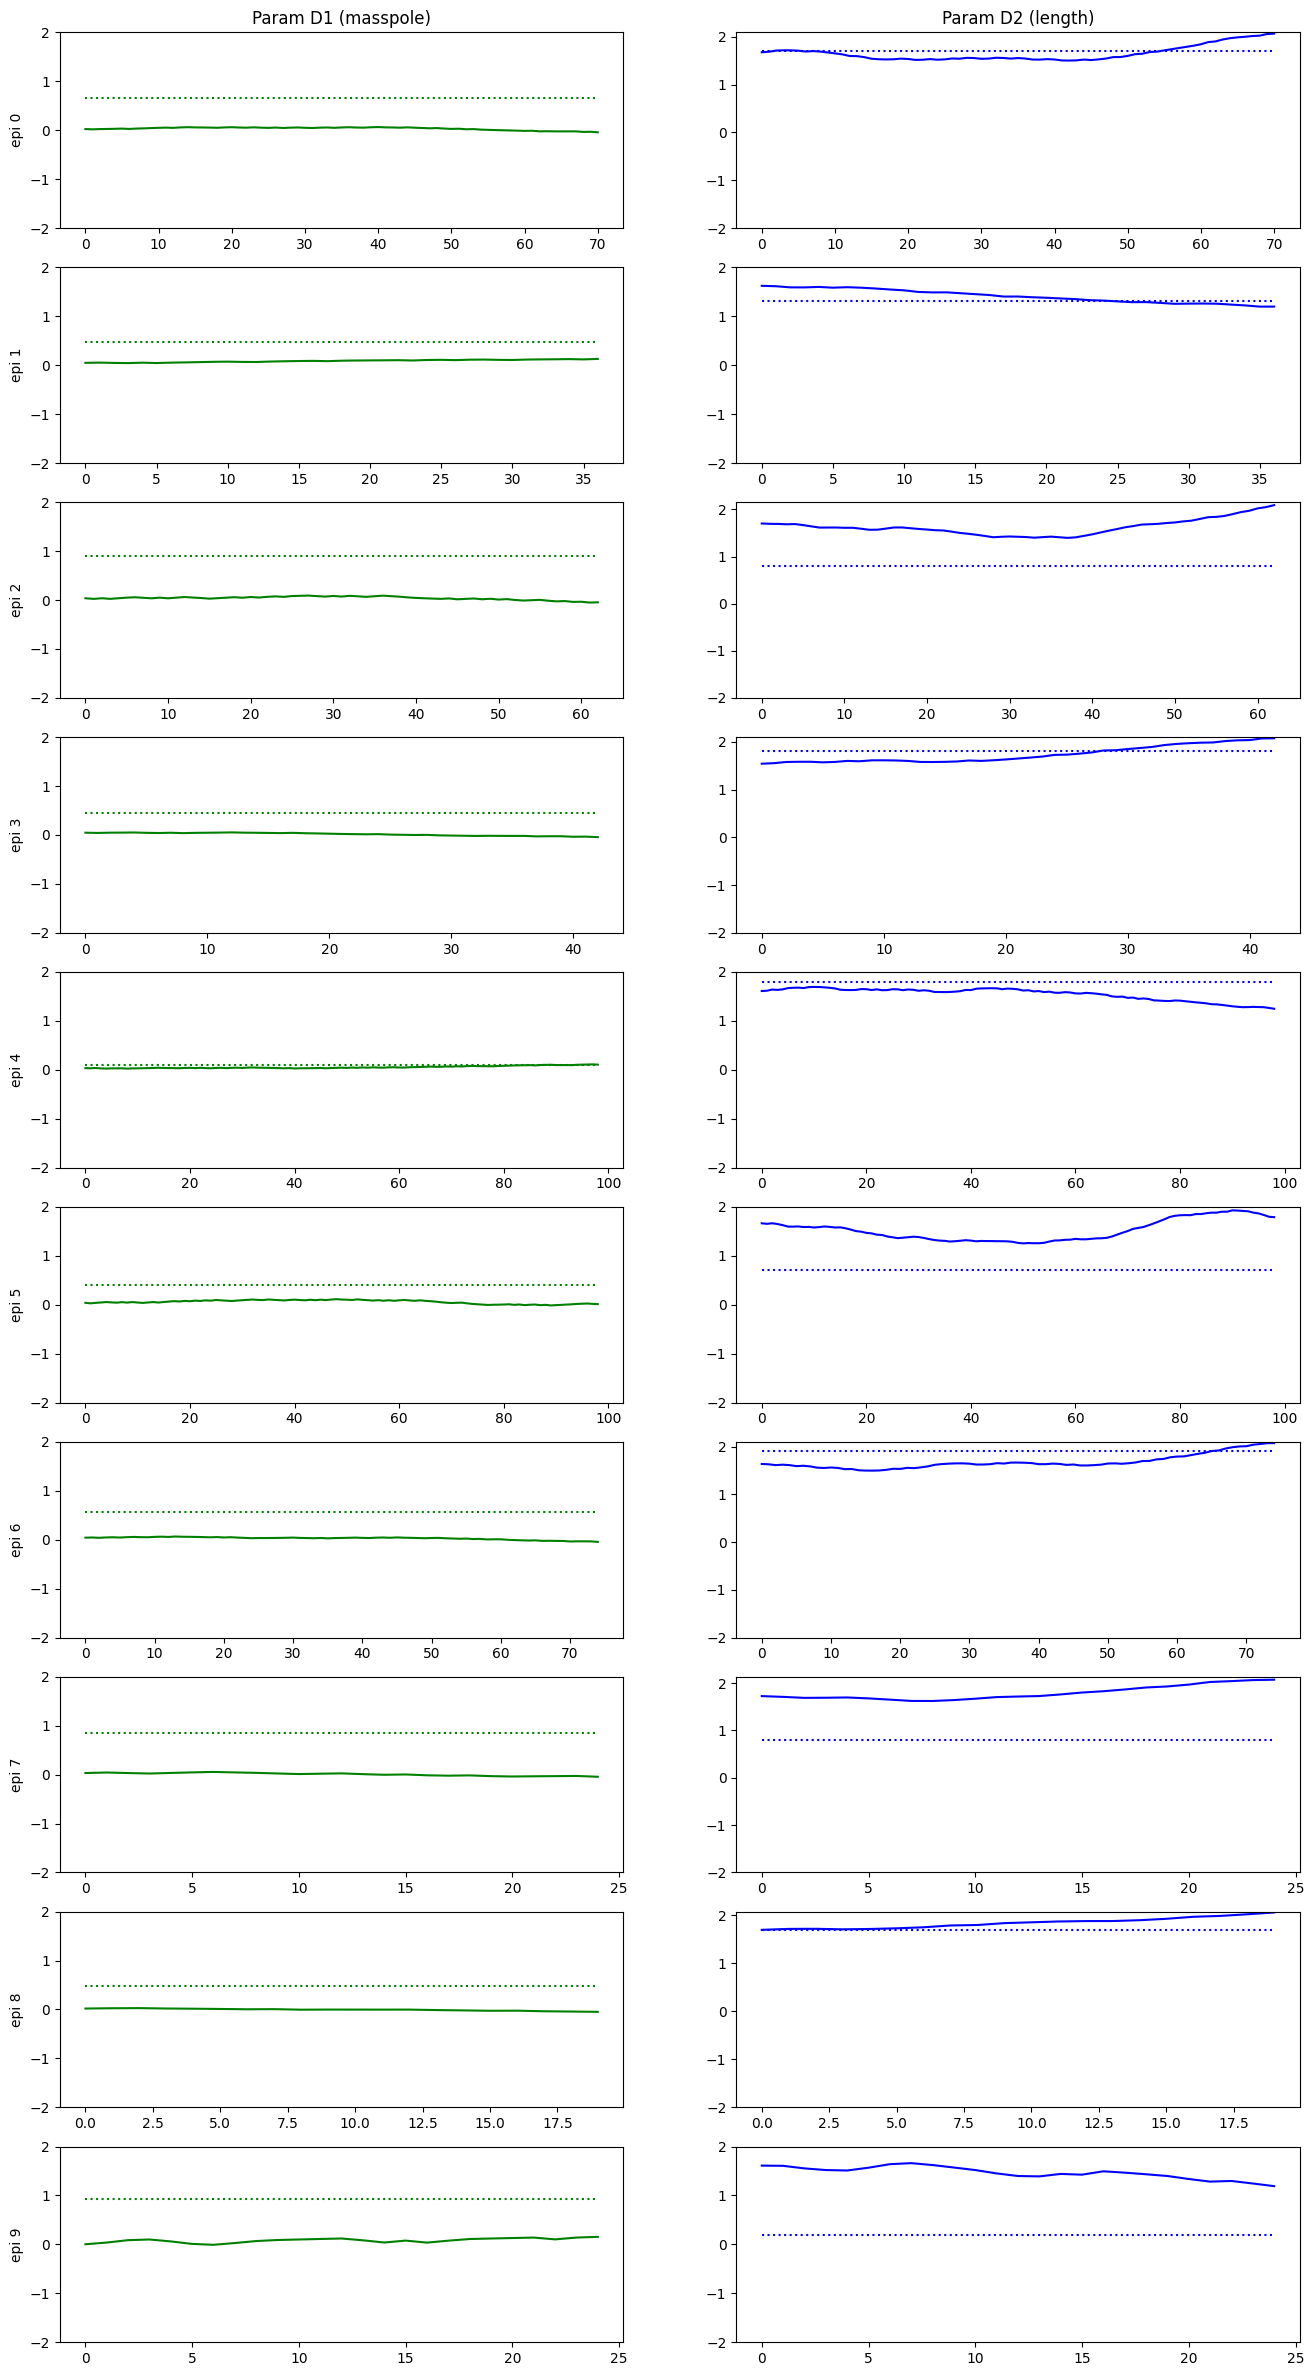

In [15]:
n = pmbrl_results.epi.drop_duplicates().size

fig, axs = plt.subplots(n, 2, figsize=(16, n*3))

axs[0][0].set_title('Param D1 (masspole)')
axs[0][1].set_title('Param D2 (length)')


for i in range(n):
    add_plot(
        f'epi {i}', 
        pmbrl_results[pmbrl_results.epi==i].reset_index(), 
        axs[i], 
        (
            pmbrl_results[pmbrl_results.epi==i].reset_index().reff_p_0, 
            pmbrl_results[pmbrl_results.epi==i].reset_index().reff_p_1
        )
    )

plt.show()